![display relevant image here](path/url/to/image)
- Banner/header image

# Title
- Relevant to Data and Business Context

## Overview
- BLUF (Bottom Line Up Front)
- One paragraph summary of final model performance and business implications
- Frame your 'story'

## Business Understanding

1. Begin by thoroughly analyzing the business context of FinTech Innovations' loan approval process. Write a short summary that:
- Describes the current manual process and its limitations
- Identifies key stakeholders and their needs
- Explains the implications of different types of model errors
- Justifies your choice between classification and regression approaches

2. Define your modeling goals and success criteria:
- Select appropriate evaluation metrics based on business impact
- You must use at least two different metrics
- Consider creating custom metric
- Establish baseline performance targets
- Document your reasoning for each choice


## Data Understanding
3. Conduct comprehensive exploratory data analysis:
- Describe basic data characteristics
- Examine distributions of all features and target variables
- Investigate relationships between features
- Create visualizations to help aid in EDA
- Document potential data quality issues and their implications

4. Develop feature understanding:
- Categorize features by type (numerical, categorical, ordinal)
- Identify features requiring special preprocessing
- Document missing value patterns and their potential meanings
- Note potential feature engineering opportunities


In [ ]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns




In [ ]:
# EDA Code Here - Create New Cells As Needed
df = pd.read_csv('financial_loan_data.csv')

print(df.shape)


(20000, 35)


In [21]:

df.head()


,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,"$39,948.00",617,Employed,Master,22,13152,48,Married,2,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,38,"$39,709.00",628,Employed,Associate,15,26045,48,Single,1,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,47,"$40,724.00",570,Employed,Bachelor,26,17627,36,NaN,2,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,58,"$69,084.00",545,Employed,High School,34,37898,96,Single,1,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,37,"$103,264.00",594,Employed,Associate,17,9184,36,Married,1,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [22]:

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  str    
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  str    
 4   EducationLevel              19099 non-null  str    
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  int64  
 7   LoanDuration                20000 non-null  int64  
 8   MaritalStatus               18669 non-null  str    
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 non-null  str    
 11  MonthlyDebtPayments         20000 non-null  int64  
 12  CreditCardUtilizationRate   20000 non-null  float64
 13  NumberOfOpenCreditLines     20000 non-null

In [23]:

df.describe(include='all')

,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
count,20000.000000,20000,20000.000000,20000,19099,20000.000000,20000.000000,20000.000000,18669,20000.000000,...,20000.000000,20000.000000,20000.000000,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
unique,NaN,17516,NaN,3,5,NaN,NaN,NaN,4,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,"$15,000.00",NaN,Employed,Bachelor,NaN,NaN,NaN,Married,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,584,NaN,17036,5804,NaN,NaN,NaN,9370,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,39.752600,NaN,571.612400,NaN,NaN,17.522750,24882.867800,54.057000,NaN,1.517300,...,4891.715521,0.799918,5.002650,7.229432e+04,0.239124,0.239110,911.607052,0.402182,0.239000,50.766780
std,11.622713,NaN,50.997358,NaN,NaN,11.316836,13427.421217,24.664857,NaN,1.386325,...,3296.771598,0.120665,2.236804,1.179200e+05,0.035509,0.042205,674.583473,0.338924,0.426483,7.778262
min,18.000000,NaN,343.000000,NaN,NaN,0.000000,3674.000000,12.000000,NaN,0.000000,...,1250.000000,0.259203,0.000000,1.000000e+03,0.130101,0.113310,97.030193,0.016043,0.000000,28.800000
25%,32.000000,NaN,540.000000,NaN,NaN,9.000000,15575.000000,36.000000,NaN,0.000000,...,2629.583333,0.727379,3.000000,8.734750e+03,0.213889,0.209142,493.763700,0.179693,0.000000,46.000000
50%,40.000000,NaN,578.000000,NaN,NaN,17.000000,21914.500000,48.000000,NaN,1.000000,...,4034.750000,0.820962,5.000000,3.285550e+04,0.236157,0.235390,728.511452,0.302711,0.000000,52.000000
75%,48.000000,NaN,609.000000,NaN,NaN,25.000000,30835.000000,72.000000,NaN,2.000000,...,6163.000000,0.892333,6.000000,8.882550e+04,0.261533,0.265532,1112.770759,0.509214,0.000000,56.000000


In [24]:
# Missing values
df.isnull().sum().sort_values(ascending=False)

MaritalStatus                 1331
EducationLevel                 901
SavingsAccountBalance          572
CreditScore                      0
AnnualIncome                     0
Age                              0
Experience                       0
LoanAmount                       0
LoanDuration                     0
NumberOfDependents               0
EmploymentStatus                 0
MonthlyDebtPayments              0
CreditCardUtilizationRate        0
NumberOfOpenCreditLines          0
NumberOfCreditInquiries          0
DebtToIncomeRatio                0
BankruptcyHistory                0
LoanPurpose                      0
HomeOwnershipStatus              0
PreviousLoanDefaults             0
PaymentHistory                   0
LengthOfCreditHistory            0
CheckingAccountBalance           0
TotalAssets                      0
TotalLiabilities                 0
MonthlyIncome                    0
UtilityBillsPaymentHistory       0
JobTenure                        0
NetWorth            

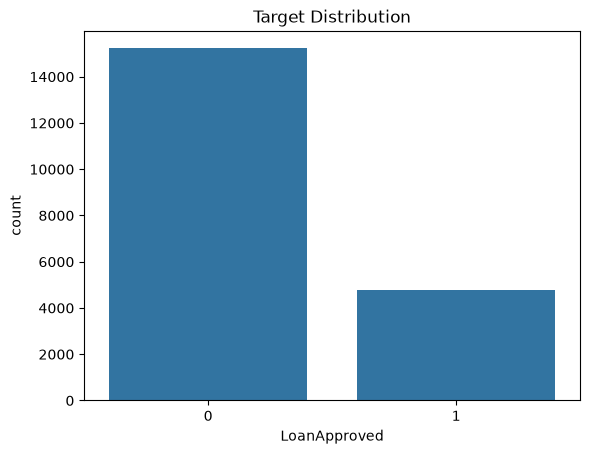

In [26]:
# Target distribution (adjust target column name)

TARGET = 'LoanApproved'
df[TARGET]
sns.countplot(x=TARGET, data=df)
plt.title('Target Distribution')
plt.show()

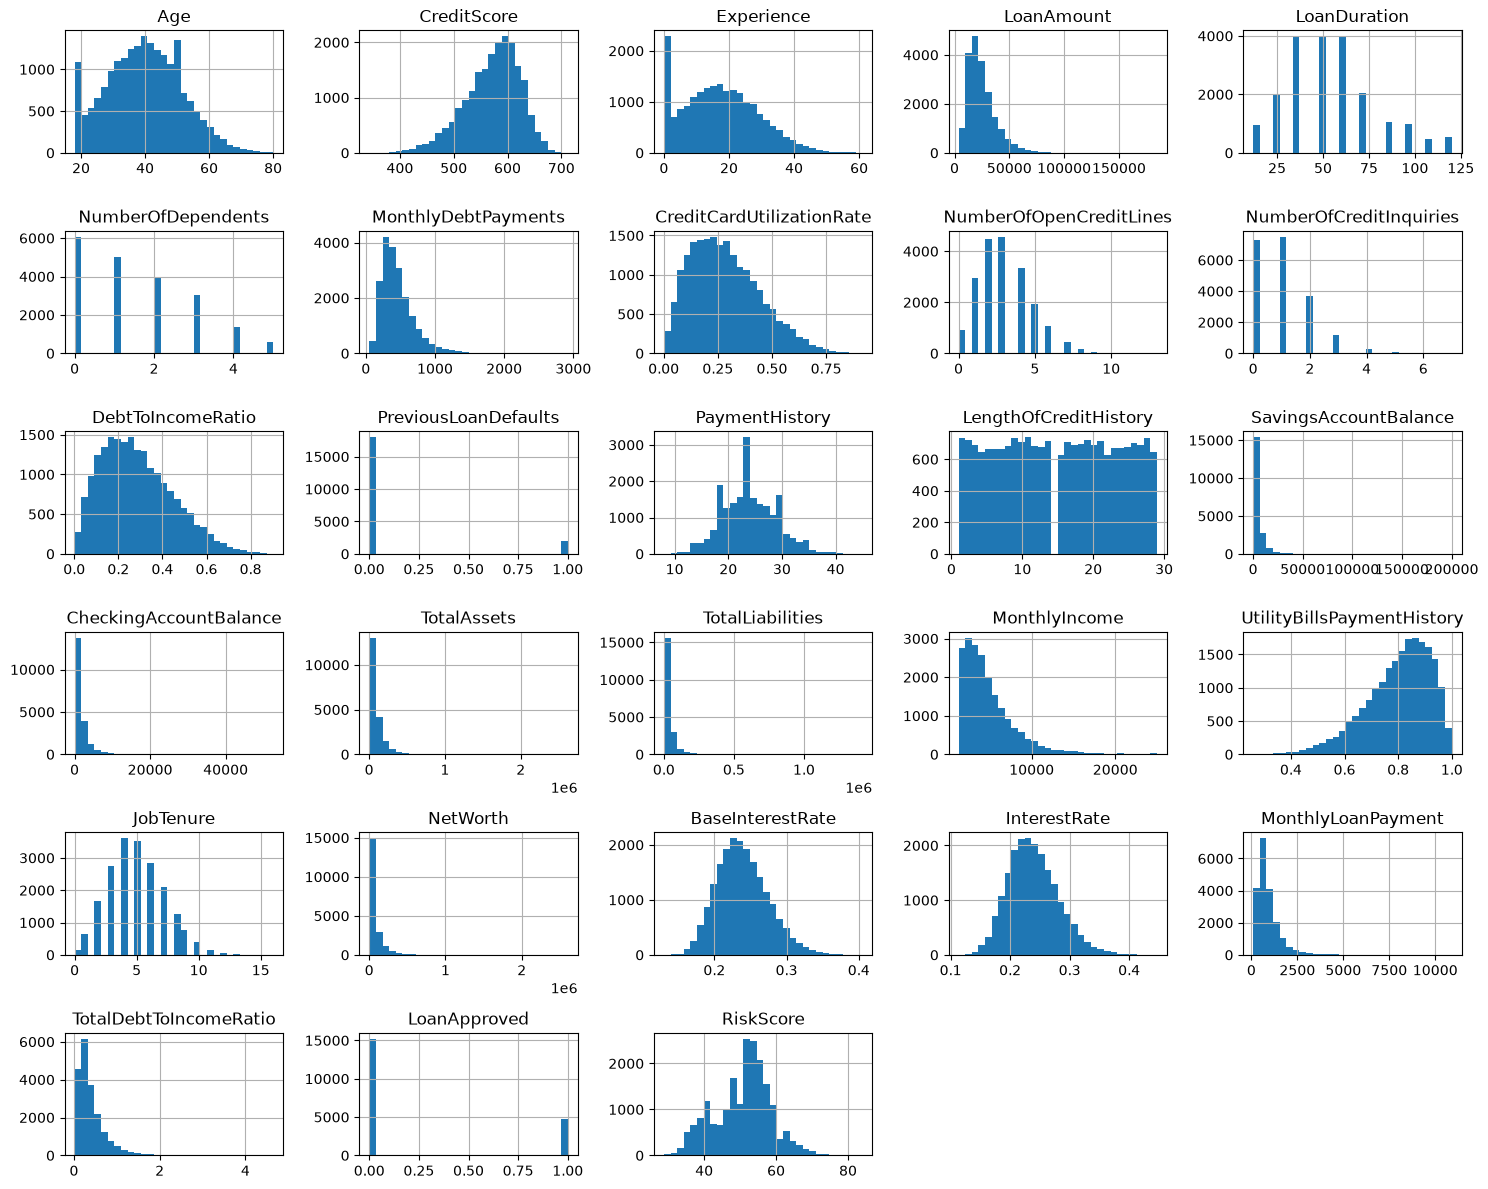

In [27]:
# Numeric distributions
num_cols = df.select_dtypes(include=np.number).columns.tolist()
df[num_cols].hist(figsize=(15, 12), bins=30)
plt.tight_layout()
plt.show()

In [32]:
'''# Correlation heatmap
plt.figure(figsize=(16, 11))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()'''

"# Correlation heatmap\nplt.figure(figsize=(16, 11))\nsns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')\nplt.title('Correlation Matrix')\nplt.show()"

In [31]:
# Categorical feature analysis
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols[:5]:
    print(f"\n{col} value counts:")
    print(df[col].value_counts().head(10))


AnnualIncome value counts:
AnnualIncome
$15,000.00     584
$300,000.00     26
$24,627.00       4
$26,437.00       4
$34,958.00       4
$36,604.00       4
$68,064.00       4
$26,721.00       4
$40,615.00       3
$18,248.00       3
Name: count, dtype: int64

EmploymentStatus value counts:
EmploymentStatus
Employed         17036
Self-Employed     1573
Unemployed        1391
Name: count, dtype: int64

EducationLevel value counts:
EducationLevel
Bachelor       5804
High School    5592
Associate      3850
Master         2933
Doctorate       920
Name: count, dtype: int64

MaritalStatus value counts:
MaritalStatus
Married     9370
Single      5665
Divorced    2704
Widowed      930
Name: count, dtype: int64

HomeOwnershipStatus value counts:
HomeOwnershipStatus
Mortgage    7939
Rent        6087
Own         3938
Other       2036
Name: count, dtype: int64


C:\Users\HomePC\AppData\Local\Temp\ipykernel_28932\3085731752.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


## Data Preparation
5. Design your preprocessing strategy:
- Create separate preprocessing flows for different feature types
- Must utilize ColumnTransformer and Pipeline
- Consider using FeatureUnion as well
- Handle missing values appropriately for each feature
- Handle Categorical and Ordinal data appropriately
- Scale numeric values if model requires it (linear model)
- Document your reasoning for each preprocessing decision



In [33]:
# Data Prep Code Here - Create New Cells As Needed
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

# Clean currency column
def clean_currency(x):
    if isinstance(x, str):
        return float(x.replace('$', '').replace(',', ''))
    return x

df['AnnualIncome'] = df['AnnualIncome'].apply(clean_currency)


In [34]:

# Define target and features
TARGET = 'LoanApproved'
X = df.drop(columns=[TARGET, 'RiskScore'])  # drop RiskScore to avoid leakage
y = df[TARGET]


In [39]:

# Categorize features manually after inspection
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()


C:\Users\HomePC\AppData\Local\Temp\ipykernel_28932\192879707.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()


In [40]:
# Ordinal features
ordinal_features = ['EducationLevel']
ordinal_categories = [['High School', 'Associate', 'Bachelor', 'Master', 'Doctorate']]

# Remove ordinal from categorical
categorical_features = [c for c in categorical_features if c not in ordinal_features]


In [ ]:
# Preprocessing pipelines
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

ordinal_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=ordinal_categories, handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features),
    ('ord', ordinal_transformer, ordinal_features)
])


## Modeling
6. Implement your modeling approach:
- Choose appropriate model algorithms based on your problem definition
- Set up validation strategy with chosen metrics
- Use a train test split and cross validation
- Create complete pipeline including any preprocessing and model
- Document your reasoning for each modeling decision

7. Optimize your model:
- Define parameter grid based on your understanding of the algorithms
- Implement GridSearchCV and/or RandomizedSearchCV with chosen metrics
- Consider tuning preprocessing steps
- Track and document the impact of different parameter combinations
- Consider the trade-offs between different model configurations

NOTE: Be mindful of time considerations - showcase “how to tune” 


In [43]:
#  Modeling Code Here - Create New Cells as Needed
from sklearn.model_selection import StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.metrics import make_scorer, confusion_matrix, roc_auc_score, average_precision_score

# Custom cost function
def expected_cost(y_true, y_pred, cost_fn=8000, cost_fp=50000):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return cost_fn * fn + cost_fp * fp


In [44]:

# Scorer for GridSearchCV (maximizes negative cost)
def cost_scorer(estimator, X, y):
    y_pred = estimator.predict(X)
    return -expected_cost(y, y_pred)


In [45]:

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [48]:
# Model comparison
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
}

results = []
for name, model in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('model', model)])
    auc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc').mean()
    pr_auc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='average_precision').mean()
    cost = -cross_val_score(pipe, X_train, y_train, cv=cv, scoring=cost_scorer).mean()
    results.append({'Model': name, 'ROC-AUC': auc, 'PR-AUC': pr_auc, 'Expected Cost': cost})

pd.DataFrame(results).sort_values('Expected Cost')

,Model,ROC-AUC,PR-AUC,Expected Cost
2,Gradient Boosting,0.985228,0.958530,4526400.0
0,Logistic Regression,0.994644,0.983920,5848400.0
1,Random Forest,0.976729,0.931689,8263200.0


In [49]:
# Hyperparameter tuning : Logistic Regression
log_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

param_dist = {
    'model__C': [0.1, 1, 10],
    'model__penalty': ['l1', 'l2'],
    'model__solver': ['liblinear', 'saga']
}

log_search = RandomizedSearchCV(
    log_pipe, param_dist, n_iter=20, cv=cv,
    scoring=cost_scorer, random_state=42, n_jobs=-1, verbose=1
)
log_search.fit(X_train, y_train)
print("Best params:", log_search.best_params_)
print("Best cost:", -log_search.best_score_)

c:\Users\HomePC\.venv\Lib\site-packages\sklearn\model_selection\_search.py:326: UserWarning: The total space of parameters 12 is smaller than n_iter=20. Running 12 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 5 folds for each of 12 candidates, totalling 60 fits


c:\Users\HomePC\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\HomePC\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Best params: {'model__solver': 'liblinear', 'model__penalty': 'l1', 'model__C': 10}
Best cost: 5538400.0


In [50]:
# Hyperparameter tuning : Random Forest
rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(class_weight='balanced', random_state=42))
])

param_dist = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__class_weight': ['balanced', 'balanced_subsample']
}

rf_search = RandomizedSearchCV(
    rf_pipe, param_dist, n_iter=20, cv=cv,
    scoring=cost_scorer, random_state=42, n_jobs=-1, verbose=1
)
rf_search.fit(X_train, y_train)
print("Best params:", rf_search.best_params_)
print("Best cost:", -rf_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_depth': 30, 'model__class_weight': 'balanced_subsample'}
Best cost: 4779600.0


In [52]:
# Hyperparameter tuning : Gradient Boosting
gb_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingClassifier(random_state=42))
])
param_dist = {
    'model__n_estimators': [100, 200, 300],
    'model__learning_rate': [0.01, 0.1, 0.2],
    'model__max_depth': [3, 5, 7],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

gb_search = RandomizedSearchCV(
    gb_pipe, param_dist, n_iter=20, cv=cv,  
    scoring=cost_scorer, random_state=42, n_jobs=-1, verbose=1
)
gb_search.fit(X_train, y_train)
print("Best params:", gb_search.best_params_)
print("Best cost:", -gb_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'model__n_estimators': 300, 'model__min_samples_split': 10, 'model__min_samples_leaf': 1, 'model__max_depth': 3, 'model__learning_rate': 0.2}
Best cost: 3420000.0


In [54]:
# Threshold optimization on test set
best_model = rf_search.best_estimator_
y_proba = best_model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.05, 0.95, 0.01)
costs = [expected_cost(y_test, (y_proba >= t).astype(int)) for t in thresholds]
best_threshold = thresholds[np.argmin(costs)]
print(f"Best threshold: {best_threshold:.2f}, Cost: {min(costs):,.0f}")

Best threshold: 0.63, Cost: 3,530,000


## Evaluation and Conclusion
8. Conduct thorough evaluation of final model:
- Assess models test data performance using your defined metrics
- Analyze performance across different data segments
- Identify potential biases or limitations
- Visualize model performance
    - Classification: Confusion Matrix/ROC-AUC
    - Regression: Scatter Plot (Predicted vs. Actual values)

9. Extract and interpret feature importance/significance:
- Which features had the most impact on your model?
- Does this lead to any potential business recommendations?

10. Prepare your final deliverable:
- Technical notebook with complete analysis
- Executive summary for business stakeholders
- Recommendations for implementation
- Documentation of potential improvements